## **BOSQUES ALEATORIOS**

Un bosque aleatorio (o Random Forest) es un algoritmo de aprendizaje automático que combina las predicciones de múltiples árboles de decisión individuales para entregar un único resultado final más preciso y estable. Funciona bajo el principio de "la sabiduría de las masas", donde la combinación de muchos modelos corregir el error de predicción de un solo árbol.

FUNCIONAMIENTO:

Muestreo aleatorio (Bagging): El algoritmo crea diferentes subconjuntos de los datos originales utilizando muestreo con reemplazo (bootstrapping). Cada árbol del bosque se entrena con un subconjunto distinto.

Selección de características al azar: Al construir los nodos de cada árbol, el algoritmo selecciona solo un grupo aleatorio de variables o atributos. Esto hace que los árboles sean diferentes entre sí y estén descorrelacionados.

Predicción final: Cada árbol emite su propio diagnóstico o valor:

Clasificación: Se elige la opción con votación mayoritaria.

Regresión: Se calcula el promedio de todas las respuestas.

Importar librerías

In [22]:
import pandas as pd
import seaborn as sns
import numpy as np
import random

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris #Conjunto de datos Iris
from sklearn.model_selection import train_test_split #Para partición del conjunto de datos en entrenamiento y prueba
from sklearn.ensemble import RandomForestClassifier #Modelo de bosques aleatorios
from sklearn.preprocessing import LabelEncoder #Para convertir etiquetas
from sklearn.metrics import mean_absolute_error, mean_squared_error #Para validación con cálculo de errores en predicciones
from sklearn.metrics import ConfusionMatrixDisplay #Matriz de confusión (para validación)

Cargar conjunto de datos

In [2]:
#Cargar conjunto de datos
iris = load_iris()

#Convertir a pandas (dataframe - df)
iris_features = pd.DataFrame(data=iris.data, columns=iris.feature_names) #Características X

Definir entradas como matriz X

In [3]:
X = iris_features.copy()
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Codificar variables categóricas (nombres de especies) en variables numéricas (0, 1 o 2)

In [4]:
le = LabelEncoder()
encod = le.fit_transform(iris.target_names)
print(encod)

[0 1 2]


Partir el conjunto de datos en entrenamiento (66%) y validación (33%)

El parámetro "random_state" sirve para controlar la aleatoriedad y siempre, aunque aleatoria, hacer la partición de la misma manera, lo cual es útil para hacer la partición en diferentes simulaciones y con diferentes modelos con la misma partición.

In [5]:
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.33, random_state=101)
print('X_train: ', X_train.shape)
print('X_test: ', X_test.shape)
print('y_train: ', y_train.shape)
print('y_test: ', y_test.shape)

X_train:  (100, 4)
X_test:  (50, 4)
y_train:  (100,)
y_test:  (50,)


Modelo

In [8]:
# Usamos 5 árboles de decisión en nuestro bosque
bosque1 = RandomForestClassifier(n_estimators=5, random_state=42)

# 4. Entrenar el modelo
bosque1.fit(X_train, y_train)

RandomForestClassifier(n_estimators=5, random_state=42)

Se realizan predicciones sobre el subconjunto de validación (test) que no participó durante el entrenamiento.

In [13]:
pred = bosque1.predict(X_test)
print(pred)

[0 0 0 2 1 2 1 1 2 0 2 0 0 2 2 1 1 1 0 2 1 0 1 1 1 1 1 2 0 0 2 1 2 1 2 1 1
 1 1 2 0 0 0 2 1 0 2 1 0 1]


Validar

In [14]:
print('MSE:', mean_squared_error(y_test, pred))

MSE: 0.02


Modificar hiperarámetros para tratar de mejorar el modelo

In [19]:
bosque2 = RandomForestClassifier(n_estimators=10, random_state=42, bootstrap=True) #Ahora con 100 árboles
bosque2.fit(X_train, y_train) #Se entrena el modelo con el subconjunto "train"
pred = bosque2.predict(X_test)
print('MSE:', mean_squared_error(y_test, pred))

MSE: 0.06


Probar varias configuraciones para el hiperparámetro de profundidad de los árboles, entrenando y validando varios modelos iterativamente.

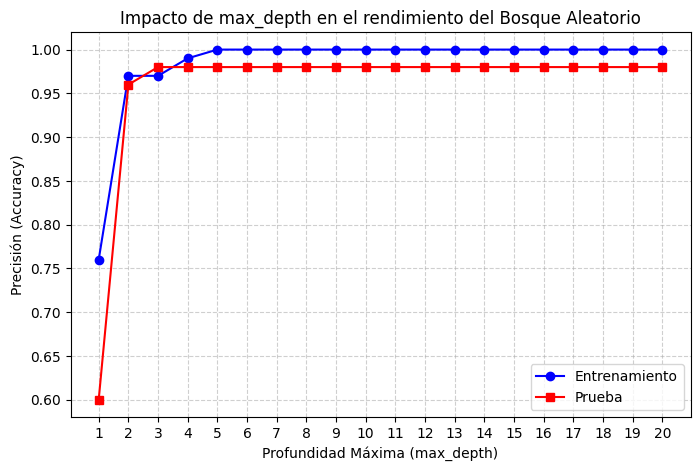

In [25]:
profundidades = np.arange(1, 21)
precision_entrenamiento = []
precision_prueba = []

#Entrenar y evaluar el modelo para cada profundidad
for depth in profundidades:
    # Creamos el bosque con la profundidad actual
    modelo = RandomForestClassifier(
        n_estimators=50, max_depth=depth, random_state=42
    )
    modelo.fit(X_train, y_train)

    # Guardamos la precisión de entrenamiento
    acc_train = modelo.score(X_train, y_train)
    precision_entrenamiento.append(acc_train)

    # Guardamos la precisión de prueba
    acc_test = modelo.score(X_test, y_test)
    precision_prueba.append(acc_test)

# 4. Generar la gráfica de rendimiento
plt.figure(figsize=(8, 5))
plt.plot(
    profundidades,
    precision_entrenamiento,
    label="Entrenamiento",
    marker="o",
    color="blue",
)
plt.plot(
    profundidades, precision_prueba, label="Prueba", marker="s", color="red"
)

plt.title("Impacto de max_depth en el rendimiento del Bosque Aleatorio")
plt.xlabel("Profundidad Máxima (max_depth)")
plt.ylabel("Precisión (Accuracy)")
plt.xticks(profundidades)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

Se concluye entonces que para profundidades a partir de max_depth=3 el modelo no mejora, encontrando los resultados óptimos entre todos los modelos entrenados.